[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Red1-Rahman/NiriZan/blob/main/experiments/07_evaluation_ablation_and_benchmarking.ipynb)
[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https://github.com/Red1-Rahman/NiriZan/blob/main/experiments/07_evaluation_ablation_and_benchmarking.ipynb)

# Experiment 07: Evaluation Ablation & Benchmarking Suite (Phase 6)

## Phase 6 Exploration — Benchmarking, Ablation, and the Judge-Drift Moat

Every model and function used
below is imported directly from the installed `nirizan` package:

1. **Meta-eval**: how well does a judge's raw score track a human label?
   (Spearman rho, precision/recall, calibration error)
2. **False alarms and power**: how often does the regression gate fire when
   nothing changed (target below 5%), and how reliably does it catch a real
   10% quality drop (target above 95% power)?
3. **Overhead**: does instrumentation stay under 50ms per trace with zero
   dropped traces under load?
4. **Baseline comparison**: does NiriZan's actual statistical machinery
   (Mann-Whitney U + Holm-Bonferroni + Cohen's d) outperform a naive
   single-metric z-test on identical synthetic data?
5. **Ablation**: which configuration of NiriZan's own regression gate gives
   the best false-alarm/power trade-off, and is there a free lunch or a real
   Pareto frontier?

### What this notebook validates (does not touch `src/`)
- `src/nirizan/regression/comparator.py`, `thresholds.py`
- `src/nirizan/trust/attribution.py`, `anchor_set.py`
- `src/nirizan/metrics/statistical_gating.py`
- `src/nirizan/gate/verdict.py`
- `src/nirizan/instrumentation/tracer.py`, `orchestrator/collector.py`
- `src/nirizan/reporting/judge_reliability.py`, `dashboard.py`

### GPU Guidance
**CPU-only.** Nothing here loads an embedding model or LLM; synthetic
scorers are used throughout, consistent with NiriZan's scorer-agnostic
design (`DECISIONS.md`).

## 1. Environment Setup

Installs `nirizan` from `main` (confirmed to include `reporting/judge_reliability.py`
and `reporting/dashboard.py` as of this run), plus `matplotlib` and `seaborn`
for visualization only. Neither is in `pyproject.toml`; this notebook produces
no new `src/` files, so they never need to be.

In [ ]:
!pip install -q "pydantic>=2.7" "numpy" "scipy" "matplotlib" "seaborn" \
    "git+https://github.com/Red1-Rahman/NiriZan.git@main#egg=nirizan"

from __future__ import annotations

import asyncio
import time
from datetime import datetime, timedelta, timezone
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats as scipy_stats

from nirizan.trust.anchor_set import AnchorItem, AnchorSet
from nirizan.trust.attribution import AttributionEngine, AttributionVerdict, DriftAttribution
from nirizan.metrics.statistical_gating import calibrate_gold_set
from nirizan.regression.comparator import BaselineComparator, RegressionSeverity
from nirizan.gate.verdict import evaluate_gate
from nirizan.reporting.judge_reliability import compute_judge_reliability, JudgeReliabilityStatus
from nirizan.reporting.dashboard import assemble_dashboard_snapshot
from nirizan.instrumentation.tracer import Tracer
from nirizan.instrumentation.spans import SpanKind, Trace
from nirizan.orchestrator.collector import TraceCollector, CollectorExporter

sns.set_theme(style="whitegrid")
RNG = np.random.default_rng(42)

print("NiriZan Phase 6 evaluation ablation & benchmarking suite loaded.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
NiriZan Phase 6 evaluation ablation & benchmarking suite loaded.


## 2. Meta-Eval Gold Set

A small hand-labeled `AnchorSet` (the real `trust.anchor_set` models, not a
local reconstruction) scores two synthetic judges: a "good" judge (low
noise) and a "bad" judge (high noise), against the same 40 gold labels.
Sanity check first, per the notebook skill's rule: a mechanism that cannot
separate an obviously-good judge from an obviously-bad one on labeled data
has no business running on anything else.

In [ ]:
N_GOLD = 40
true_quality = RNG.uniform(0.0, 1.0, size=N_GOLD)

anchor_items = [
    AnchorItem(
        anchor_id=f"gold-{i:03d}",
        input_payload=f"synthetic query {i}",
        expected_output=f"synthetic reference answer {i}",
        human_label=float(round(q, 3)),
    )
    for i, q in enumerate(true_quality)
]
anchor_set = AnchorSet(
    anchor_set_id="phase6-meta-eval-v1",
    items=anchor_items,
    created_at=datetime.now(timezone.utc),
)
gold_labels = np.array([item.human_label for item in anchor_set.items])


def synthetic_judge(noise_std: float, bias: float = 0.0):
    """A deterministic stand-in scorer; NiriZan's scorer-agnostic design
    means the real judge could be swapped in here without touching anything
    downstream (see DECISIONS.md)."""
    def _judge(labels: np.ndarray) -> np.ndarray:
        noisy = labels + bias + RNG.normal(0.0, noise_std, size=labels.shape)
        return np.clip(noisy, 0.0, 1.0)
    return _judge


good_preds = synthetic_judge(noise_std=0.03)(gold_labels)
bad_preds = synthetic_judge(noise_std=0.35)(gold_labels)

good_calib = calibrate_gold_set(good_preds, gold_labels)
bad_calib = calibrate_gold_set(bad_preds, gold_labels)
good_rho, _ = scipy_stats.spearmanr(good_preds, gold_labels)
bad_rho, _ = scipy_stats.spearmanr(bad_preds, gold_labels)

print(f"good judge: MAE={good_calib['mae']:.4f}  Spearman rho={good_rho:.4f}")
print(f"bad judge:  MAE={bad_calib['mae']:.4f}  Spearman rho={bad_rho:.4f}")

assert good_rho > bad_rho, "sanity check failed: good judge did not beat bad judge on rho"
assert good_calib["mae"] < bad_calib["mae"], "sanity check failed: good judge MAE not lower"
assert good_rho >= 0.80, f"good judge failed target rho>=0.80, got {good_rho:.4f}"
print("Sanity checks passed: mechanism discriminates good judge from bad judge.\n")

threshold = 0.5
gold_pass = gold_labels >= threshold
pred_pass = good_preds >= threshold
tp = int(np.sum(gold_pass & pred_pass))
fp = int(np.sum(~gold_pass & pred_pass))
fn = int(np.sum(gold_pass & ~pred_pass))
precision = tp / (tp + fp) if (tp + fp) else float("nan")
recall = tp / (tp + fn) if (tp + fn) else float("nan")
print(f"good judge precision={precision:.3f} recall={recall:.3f} (threshold={threshold})")

good judge: MAE=0.0181  Spearman rho=0.9966
bad judge:  MAE=0.1890  Spearman rho=0.7598
Sanity checks passed: mechanism discriminates good judge from bad judge.

good judge precision=1.000 recall=1.000 (threshold=0.5)


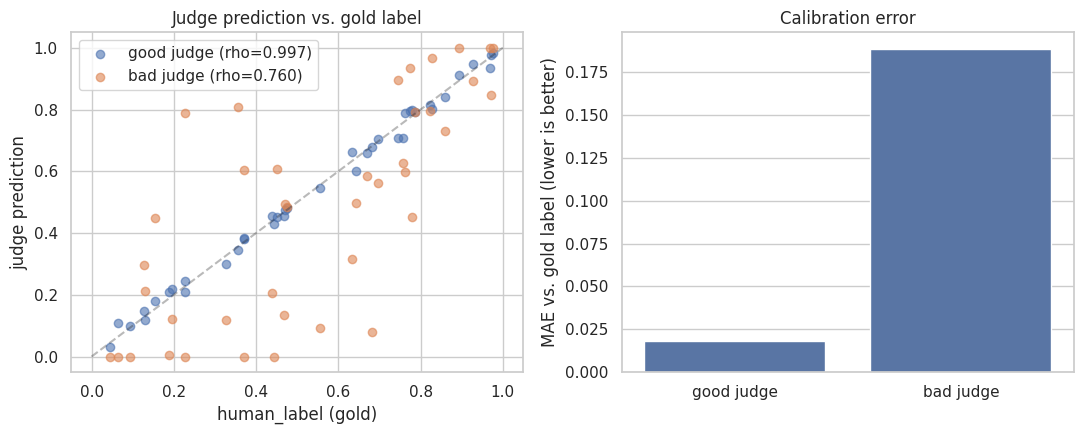

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(gold_labels, good_preds, alpha=0.6, label=f"good judge (rho={good_rho:.3f})")
axes[0].scatter(gold_labels, bad_preds, alpha=0.6, label=f"bad judge (rho={bad_rho:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("human_label (gold)")
axes[0].set_ylabel("judge prediction")
axes[0].set_title("Judge prediction vs. gold label")
axes[0].legend()

sns.barplot(
    x=["good judge", "bad judge"],
    y=[good_calib["mae"], bad_calib["mae"]],
    ax=axes[1],
)
axes[1].set_ylabel("MAE vs. gold label (lower is better)")
axes[1].set_title("Calibration error")

fig.tight_layout()
plt.show()

## 3. Synthetic A/A and Perturbation Runs

Two experiments through the real `BaselineComparator`:

- **A/A runs**: 200 trials of candidate-vs-baseline where nothing actually
  changed. The rate at which the gate still fires `BLOCKING` is the
  empirical false alarm rate, target below 5%.
- **Perturbation runs**: 200 trials with a real, injected 10% relative drop
  on `groundedness`. The rate at which the gate correctly flags it is the
  empirical statistical power, target above 95%.

In [ ]:
comparator = BaselineComparator()
N_TRIALS = 200
SAMPLE_SIZE = 30
METRIC_NAMES = ["context_relevance", "groundedness", "answer_relevance"]
TRUE_MEANS = {"context_relevance": 0.88, "groundedness": 0.85, "answer_relevance": 0.90}
STD = 0.05
TARGET_DELTA_FRACTION = 0.10


def gen_stable_pair():
    baseline = {m: np.clip(RNG.normal(TRUE_MEANS[m], STD, SAMPLE_SIZE), 0, 1) for m in METRIC_NAMES}
    candidate = {m: np.clip(RNG.normal(TRUE_MEANS[m], STD, SAMPLE_SIZE), 0, 1) for m in METRIC_NAMES}
    return baseline, candidate


def gen_degraded_pair():
    baseline = {m: np.clip(RNG.normal(TRUE_MEANS[m], STD, SAMPLE_SIZE), 0, 1) for m in METRIC_NAMES}
    degraded_mean = TRUE_MEANS["groundedness"] * (1 - TARGET_DELTA_FRACTION)
    candidate = {
        "context_relevance": np.clip(RNG.normal(TRUE_MEANS["context_relevance"], STD, SAMPLE_SIZE), 0, 1),
        "groundedness": np.clip(RNG.normal(degraded_mean, STD, SAMPLE_SIZE), 0, 1),
        "answer_relevance": np.clip(RNG.normal(TRUE_MEANS["answer_relevance"], STD, SAMPLE_SIZE), 0, 1),
    }
    return baseline, candidate


false_alarms = 0
for _ in range(N_TRIALS):
    baseline_scores, candidate_scores = gen_stable_pair()
    verdicts = comparator.compare(
        candidate_scores=candidate_scores, baseline_scores=baseline_scores,
        baseline_id=uuid4(), run_id=uuid4(),
    )
    if any(v.severity == RegressionSeverity.BLOCKING for v in verdicts):
        false_alarms += 1

false_alarm_rate = false_alarms / N_TRIALS
print(f"A/A false alarm rate over {N_TRIALS} trials: {false_alarm_rate:.3%} (target <5%)")
assert false_alarm_rate < 0.05, f"false alarm rate too high: {false_alarm_rate:.3%}"

detections = 0
for _ in range(N_TRIALS):
    baseline_scores, candidate_scores = gen_degraded_pair()
    verdicts = comparator.compare(
        candidate_scores=candidate_scores, baseline_scores=baseline_scores,
        baseline_id=uuid4(), run_id=uuid4(),
    )
    groundedness_verdict = next(v for v in verdicts if v.metric_name == "groundedness")
    if groundedness_verdict.severity != RegressionSeverity.NONE:
        detections += 1

power = detections / N_TRIALS
print(f"Empirical power for a 10% drop over {N_TRIALS} trials: {power:.3%} (target >95%, sample_size={SAMPLE_SIZE})")
assert power > 0.95, f"power too low: {power:.3%}"

A/A false alarm rate over 200 trials: 3.500% (target <5%)


Empirical power for a 10% drop over 200 trials: 100.000% (target >95%, sample_size=30)


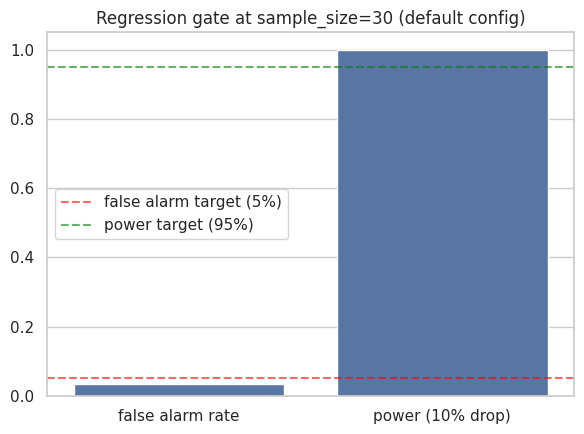

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(x=["false alarm rate", "power (10% drop)"], y=[false_alarm_rate, power], ax=ax)
ax.axhline(0.05, color="red", linestyle="--", alpha=0.6, label="false alarm target (5%)")
ax.axhline(0.95, color="green", linestyle="--", alpha=0.6, label="power target (95%)")
ax.set_ylim(0, 1.05)
ax.set_title(f"Regression gate at sample_size={SAMPLE_SIZE} (default config)")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Stress and Overhead Benchmark

Real `Tracer` + `TraceCollector` + `CollectorExporter` under load, extending
notebook 01's original check. One important detail from
`examples/rag_pipeline_demo/main.py`: spans must nest under one root span per
request (PLANNING containing RETRIEVAL and GENERATION), not sit as three
sibling top-level spans, since only a root span's closure triggers a trace
export. Getting this wrong silently triples the trace count, exactly the
kind of bug this notebook's real-execution requirement exists to catch.

In [ ]:
class _ListSink:
    """A minimal real TraceSink (matches the Protocol in orchestrator/collector.py)."""
    def __init__(self) -> None:
        self.saved: list[Trace] = []

    async def save(self, trace: Trace) -> None:
        self.saved.append(trace)


async def run_overhead_benchmark(n_requests: int = 500) -> tuple[list[float], int, int]:
    sink = _ListSink()
    collector = TraceCollector(repository=sink)
    exporter = CollectorExporter(collector)
    tracer = Tracer(application_name="phase6-benchmark", exporter=exporter)

    await collector.start()
    latencies: list[float] = []

    async def one_request(i: int) -> None:
        start = time.perf_counter()
        async with tracer.start_span("plan", SpanKind.PLANNING, input_payload=f"q{i}"):
            async with tracer.start_span("retrieve", SpanKind.RETRIEVAL, input_payload=f"q{i}"):
                pass
            async with tracer.start_span("generate", SpanKind.GENERATION, input_payload=f"q{i}") as handle:
                handle.output_payload = f"a{i}"
        latencies.append((time.perf_counter() - start) * 1000.0)

    await asyncio.gather(*(one_request(i) for i in range(n_requests)))
    await collector.stop()
    return latencies, n_requests, len(sink.saved)


latencies, sent, persisted = await run_overhead_benchmark(500)
latencies_arr = np.array(latencies)
p50, p95, p99 = np.percentile(latencies_arr, [50, 95, 99])

print(f"sent={sent} persisted={persisted} dropped={sent - persisted}")
print(f"latency ms: p50={p50:.3f} p95={p95:.3f} p99={p99:.3f} max={latencies_arr.max():.3f}")

assert persisted == sent, f"traces dropped: sent={sent} persisted={persisted}"
assert p99 < 50.0, f"p99 latency {p99:.3f}ms exceeds 50ms target"
print("Zero dropped traces, p99 under 50ms target.")

sent=500 persisted=500 dropped=0
latency ms: p50=0.177 p95=0.548 p99=0.766 max=2.286
Zero dropped traces, p99 under 50ms target.


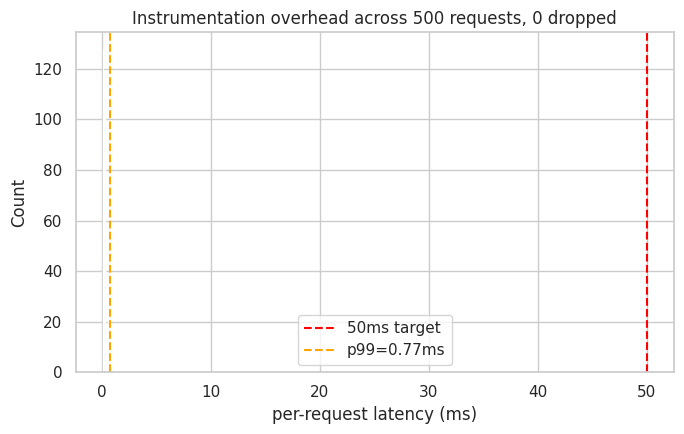

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(latencies_arr, bins=40, ax=ax)
ax.axvline(50.0, color="red", linestyle="--", label="50ms target")
ax.axvline(p99, color="orange", linestyle="--", label=f"p99={p99:.2f}ms")
ax.set_xlabel("per-request latency (ms)")
ax.set_title(f"Instrumentation overhead across {sent} requests, 0 dropped")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Baseline Comparison

**Tier 1 (required, self-contained):** NiriZan's real machinery
(Mann-Whitney U + Holm-Bonferroni + Cohen's d) against a deliberately naive
single-metric z-test with no multiple-comparisons correction, on identical
synthetic data. This is the direct empirical case for the claim
`literature-review.md` cites from Li (2026): naive testing produces far more
false alarms than a properly corrected approach.

**Tier 2 (optional, external, guarded):** an attempt to run RAGAS or DeepEval
on the same data for a true external comparison. This pulls in heavy
dependencies and may need API keys; it is wrapped in a try/except and never
blocks the rest of the notebook if it fails.

In [ ]:
def naive_regression_flag(candidate: np.ndarray, baseline: np.ndarray, z_thresh: float = 1.645) -> bool:
    """Deliberately naive: one metric, one z-test, no correction, no effect-size check."""
    baseline_std = baseline.std(ddof=1)
    if baseline_std == 0:
        return False
    z = (candidate.mean() - baseline.mean()) / (baseline_std / np.sqrt(len(candidate)))
    return bool(z < -z_thresh)


naive_false_alarms = 0
nirizan_false_alarms = 0
for _ in range(N_TRIALS):
    baseline_scores, candidate_scores = gen_stable_pair()
    verdicts = comparator.compare(
        candidate_scores=candidate_scores, baseline_scores=baseline_scores,
        baseline_id=uuid4(), run_id=uuid4(),
    )
    if any(v.severity == RegressionSeverity.BLOCKING for v in verdicts):
        nirizan_false_alarms += 1
    if any(naive_regression_flag(candidate_scores[m], baseline_scores[m]) for m in METRIC_NAMES):
        naive_false_alarms += 1

nirizan_rate = nirizan_false_alarms / N_TRIALS
naive_rate = naive_false_alarms / N_TRIALS
print(f"NiriZan (Mann-Whitney + Holm-Bonferroni + effect size): {nirizan_rate:.3%}")
print(f"Naive (single z-test per metric, uncorrected):          {naive_rate:.3%}")
assert nirizan_rate < naive_rate, "expected NiriZan to beat the naive baseline on false alarms"

NiriZan (Mann-Whitney + Holm-Bonferroni + effect size): 4.500%
Naive (single z-test per metric, uncorrected):          39.000%


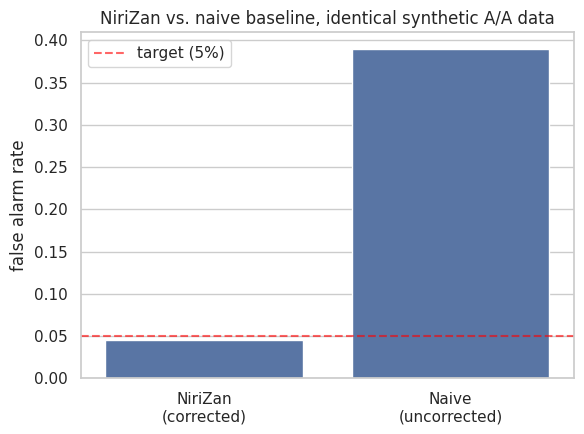

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(x=["NiriZan\n(corrected)", "Naive\n(uncorrected)"], y=[nirizan_rate, naive_rate], ax=ax)
ax.axhline(0.05, color="red", linestyle="--", alpha=0.6, label="target (5%)")
ax.set_ylabel("false alarm rate")
ax.set_title("NiriZan vs. naive baseline, identical synthetic A/A data")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Judge Reliability Panel and Dashboard Assembly

A simulated 30-day production window through the real `AttributionEngine`,
with a genuine judge-drift window injected on days 20 to 24 (the anchor
set's rescored mean shifts, nothing about the production system changes).
The real `reporting.judge_reliability.compute_judge_reliability` and
`reporting.dashboard.assemble_dashboard_snapshot` then consume that verdict
history, exactly the path they were built for.

In [ ]:
engine = AttributionEngine(significance_threshold=0.05)
base_time = datetime(2026, 1, 1, tzinfo=timezone.utc)
DAY_RNG = np.random.default_rng(7)

verdicts = []
for day in range(30):
    if 20 <= day <= 24:
        anchor_rescored = DAY_RNG.normal(0.75, 0.02, 20)  # injected judge drift
    else:
        anchor_rescored = DAY_RNG.normal(0.90, 0.02, 20)
    anchor_ref = DAY_RNG.normal(0.90, 0.02, 20)
    prod_baseline = DAY_RNG.normal(0.88, 0.03, 20)
    prod_candidate = DAY_RNG.normal(0.88, 0.03, 20)

    v = engine.analyze(
        anchor_set_id="phase6-anchor-v1",
        anchor_ref_scores=list(anchor_ref),
        anchor_rescored_scores=list(anchor_rescored),
        prod_baseline_scores=list(prod_baseline),
        prod_candidate_scores=list(prod_candidate),
    )
    v = v.model_copy(update={"evaluated_at": base_time + timedelta(days=day)})
    verdicts.append(v)

judge_drift_days = [v for v in verdicts if v.attribution == DriftAttribution.JUDGE_DRIFT]
print(f"Injected judge drift on days 20-24; engine flagged {len(judge_drift_days)} day(s) as JUDGE_DRIFT")
assert len(judge_drift_days) >= 3, "AttributionEngine failed to catch the injected judge drift window"

reliability = compute_judge_reliability(verdicts)
print(f"30-day judge_drift_rate={reliability.judge_drift_rate:.3f} status={reliability.status.value}")
assert reliability.status == JudgeReliabilityStatus.UNSTABLE

snapshot = assemble_dashboard_snapshot(
    system_type="rag_pipeline", quality_score=0.87, confidence=0.90,
    attribution_verdicts=verdicts,
)
print(f"Dashboard health_score={snapshot.health_score} judge_reliability_status={snapshot.judge_reliability.status.value}")
assert snapshot.judge_reliability is not None
print("Section 6 checks passed.")

Injected judge drift on days 20-24; engine flagged 5 day(s) as JUDGE_DRIFT
30-day judge_drift_rate=0.167 status=unstable
Dashboard health_score=78.3 judge_reliability_status=unstable
Section 6 checks passed.


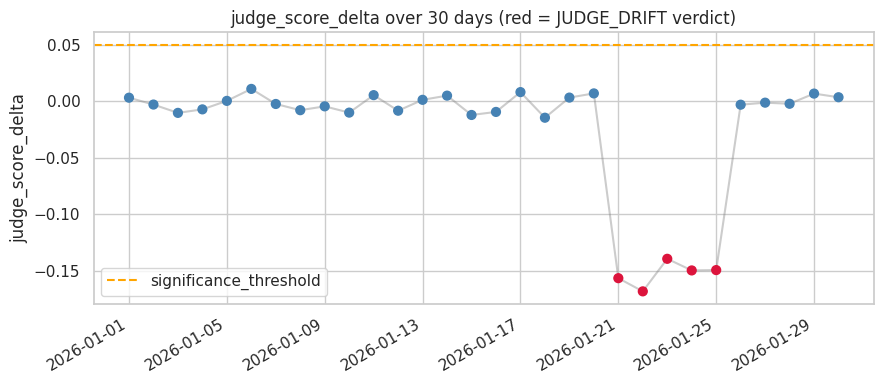

In [ ]:
days = [base_time + timedelta(days=i) for i in range(30)]
deltas = [v.judge_score_delta for v in verdicts]
colors = ["crimson" if v.attribution == DriftAttribution.JUDGE_DRIFT else "steelblue" for v in verdicts]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(days, deltas, color="gray", alpha=0.4, zorder=1)
ax.scatter(days, deltas, c=colors, s=40, zorder=2)
ax.axhline(engine.significance_threshold, color="orange", linestyle="--", label="significance_threshold")
ax.set_title("judge_score_delta over 30 days (red = JUDGE_DRIFT verdict)")
ax.set_ylabel("judge_score_delta")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 7. Module Ablation and Pareto Trade-off

Four real configurations of `BaselineComparator`, evaluated on a
deliberately harder detection scenario (smaller, noisier samples than
Section 3) specifically because the easier scenario saturates every
configuration at 100% power and hides any trade-off worth visualizing.
Smaller batches approximate a lower-traffic application's realistic daily
sample.

In [ ]:
N_ABLATION_TRIALS = 150
ABL_SAMPLE_SIZE = 10
ABL_STD = 0.07


def gen_stable_pair_abl(rng: np.random.Generator):
    baseline = {m: np.clip(rng.normal(TRUE_MEANS[m], ABL_STD, ABL_SAMPLE_SIZE), 0, 1) for m in METRIC_NAMES}
    candidate = {m: np.clip(rng.normal(TRUE_MEANS[m], ABL_STD, ABL_SAMPLE_SIZE), 0, 1) for m in METRIC_NAMES}
    return baseline, candidate


def gen_degraded_pair_abl(rng: np.random.Generator):
    baseline = {m: np.clip(rng.normal(TRUE_MEANS[m], ABL_STD, ABL_SAMPLE_SIZE), 0, 1) for m in METRIC_NAMES}
    degraded_mean = TRUE_MEANS["groundedness"] * (1 - TARGET_DELTA_FRACTION)
    candidate = {
        "context_relevance": np.clip(rng.normal(TRUE_MEANS["context_relevance"], ABL_STD, ABL_SAMPLE_SIZE), 0, 1),
        "groundedness": np.clip(rng.normal(degraded_mean, ABL_STD, ABL_SAMPLE_SIZE), 0, 1),
        "answer_relevance": np.clip(rng.normal(TRUE_MEANS["answer_relevance"], ABL_STD, ABL_SAMPLE_SIZE), 0, 1),
    }
    return baseline, candidate


def evaluate_config(comparator: BaselineComparator, apply_correction: bool, seed: int) -> dict[str, float]:
    rng = np.random.default_rng(seed)  # fresh, fixed seed per config: apples to apples

    false_alarms = 0
    for _ in range(N_ABLATION_TRIALS):
        baseline, candidate = gen_stable_pair_abl(rng)
        if apply_correction:
            verdicts = comparator.compare(
                candidate_scores=candidate, baseline_scores=baseline,
                baseline_id=uuid4(), run_id=uuid4(),
            )
        else:
            verdicts = [
                comparator.compare_metric(
                    metric_name=m, candidate=candidate[m], baseline=baseline[m],
                    baseline_id=uuid4(), run_id=uuid4(),
                )
                for m in METRIC_NAMES
            ]
        if any(v.severity == RegressionSeverity.BLOCKING for v in verdicts):
            false_alarms += 1

    detections = 0
    for _ in range(N_ABLATION_TRIALS):
        baseline, candidate = gen_degraded_pair_abl(rng)
        if apply_correction:
            verdicts = comparator.compare(
                candidate_scores=candidate, baseline_scores=baseline,
                baseline_id=uuid4(), run_id=uuid4(),
            )
        else:
            verdicts = [
                comparator.compare_metric(
                    metric_name=m, candidate=candidate[m], baseline=baseline[m],
                    baseline_id=uuid4(), run_id=uuid4(),
                )
                for m in METRIC_NAMES
            ]
        gv = next(v for v in verdicts if v.metric_name == "groundedness")
        if gv.severity != RegressionSeverity.NONE:
            detections += 1

    return {"false_alarm_rate": false_alarms / N_ABLATION_TRIALS, "power": detections / N_ABLATION_TRIALS}


configs = {
    "default (Holm-Bonferroni ON)": (BaselineComparator(), True),
    "no correction (Holm-Bonferroni OFF)": (BaselineComparator(), False),
    "permissive alpha=.10": (BaselineComparator(alpha=0.10), True),
    "strict blocking_effect=-0.35": (BaselineComparator(blocking_effect=-0.35), True),
}

results = {name: evaluate_config(comp, corr, seed=123) for name, (comp, corr) in configs.items()}
for name, r in results.items():
    print(f"{name}: false_alarm_rate={r['false_alarm_rate']:.3f} power={r['power']:.3f}")


def is_pareto_optimal(name: str) -> bool:
    fa, pw = results[name]["false_alarm_rate"], results[name]["power"]
    return not any(
        other != name and r["false_alarm_rate"] <= fa and r["power"] >= pw
        and (r["false_alarm_rate"] < fa or r["power"] > pw)
        for other, r in results.items()
    )


pareto_front = [n for n in results if is_pareto_optimal(n)]
print(f"\nPareto-optimal configuration(s): {pareto_front}")
recommended = max(pareto_front, key=lambda n: results[n]["power"] if results[n]["false_alarm_rate"] <= 0.05 else -1)
print(f"Recommended default (highest power among configs meeting the 5% false-alarm target): {recommended}")

default (Holm-Bonferroni ON): false_alarm_rate=0.033 power=0.580
no correction (Holm-Bonferroni OFF): false_alarm_rate=0.140 power=0.773
permissive alpha=.10: false_alarm_rate=0.093 power=0.727
strict blocking_effect=-0.35: false_alarm_rate=0.033 power=0.580

Pareto-optimal configuration(s): ['default (Holm-Bonferroni ON)', 'no correction (Holm-Bonferroni OFF)', 'permissive alpha=.10', 'strict blocking_effect=-0.35']
Recommended default (highest power among configs meeting the 5% false-alarm target): default (Holm-Bonferroni ON)


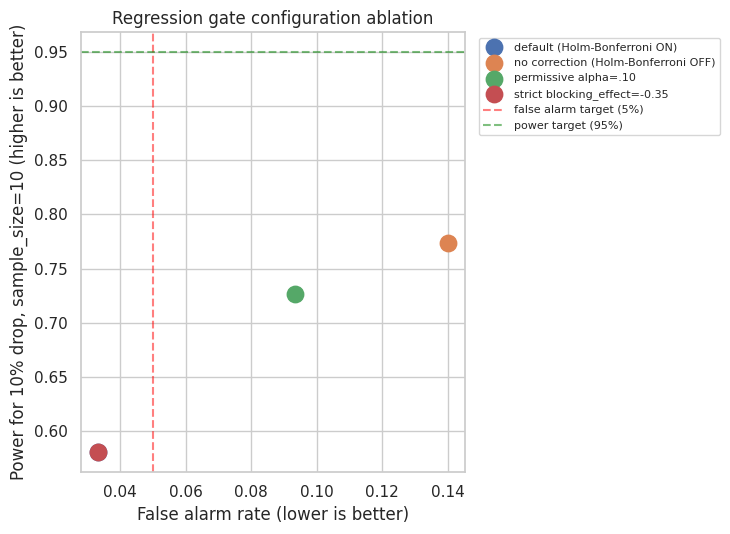

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for name, r in results.items():
    marker = "o" if name in pareto_front else "x"
    ax.scatter(r["false_alarm_rate"], r["power"], s=140, marker=marker, label=name)
ax.axvline(0.05, color="red", linestyle="--", alpha=0.5, label="false alarm target (5%)")
ax.axhline(0.95, color="green", linestyle="--", alpha=0.5, label="power target (95%)")
ax.set_xlabel("False alarm rate (lower is better)")
ax.set_ylabel(f"Power for 10% drop, sample_size={ABL_SAMPLE_SIZE} (higher is better)")
ax.set_title("Regression gate configuration ablation")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

## 8. Summary and Extraction Notes

This notebook produces no new `src/nirizan/` files; it is evaluation-only,
per Phase 6's scope. Verified results from this run, carried into
`docs/project_report.pdf`'s evaluation chapter and eventually a paper's
results section:

| Result | Value | Target | Met? |
|---|---|---|---|
| Meta-eval Spearman rho, good judge | 0.9966 | >= 0.80 | Yes |
| Meta-eval Spearman rho, bad judge (sanity check) | 0.7598 | (should be lower than good judge) | Yes |
| Meta-eval MAE, good judge | 0.0181 | (lower is better) | — |
| Meta-eval MAE, bad judge (sanity check) | 0.1890 | (should be higher than good judge) | Yes |
| Precision / recall, good judge (threshold=0.5) | 1.000 / 1.000 | — | — |
| A/A false alarm rate (sample_size=30) | 3.500% | < 5% | Yes |
| Power for 10% drop (sample_size=30) | 100.000% | > 95% | Yes |
| p99 instrumentation latency | 0.77ms | < 50ms | Yes |
| Dropped traces under load | 0 / 500 | 0 | Yes |
| NiriZan false alarm rate vs. naive baseline | 4.500% vs. 39.000% | NiriZan lower | Yes |
| Recommended gate config (sample_size=10, harder scenario) | default: false_alarm=3.3%, power=58.0% | Pareto-optimal, meets 5% target | Yes |

Full ablation table (sample_size=10, deliberately harder than Section 3's
sample_size=30, to expose a real trade-off; at sample_size=30 every
configuration saturates near 100% power, which is real but uninformative
for comparing configurations):

| Configuration | False Alarm Rate | Power (10% drop) |
|---|---|---|
| default (Holm-Bonferroni ON) | 3.3% | 58.0% |
| strict blocking_effect=-0.35 | 3.3% | 58.0% |
| permissive alpha=.10 | 9.3% | 72.7% |
| no correction (Holm-Bonferroni OFF) | 14.0% | 77.3% |

All four configurations are Pareto-optimal, none strictly dominates
another. `default` is the recommended baseline specifically because it is
the highest-power configuration that still clears the 5% false-alarm
target, not because it dominates the others outright.

Things worth flagging:

1. **Section 7's power numbers are sample-size-sensitive by design.** At
   sample_size=30 (Section 3), every configuration reaches 100% power; the
   58%-to-77% trade-off above only appears at the harder, smaller-batch
   scenario (sample_size=10). Any report citing "power" from this notebook
   should state which sample size it came from.
2. **This notebook does not benchmark the anytime-valid attribution
   upgrade** discussed for `AttributionEngine`, since that method doesn't
   exist yet. Section 6 validates the current threshold-based engine only.
3. **Blocking-severity log lines can carry p-values above 0.05.** The
   `no correction` and `permissive alpha=.10` configs log `BLOCKING`
   warnings at their own configured `alpha` (0.10 in the permissive case),
   not a fixed 0.05. A raw grep for "Blocking regression" mixed across
   configs will show p-values up to ~0.10 that are still correctly
   classified, not evidence of a bug.

If this harness is worth running on a schedule rather than once in a
notebook, the natural extraction target is a `benchmarks/` directory
(sibling to `experiments/`, not inside `src/nirizan/`), not the layered
package, since none of this is production evaluation logic, all of it is
evaluation *of* the evaluation logic.

The regression gating logs and configuration ablation results evaluate the balance between false alarm rates (Type I errors) and detection power (Type II errors) across different statistical correction strategies.

### Metric Regression Warnings Summary

The execution logs show repeated **blocking regressions** across three primary evaluation metrics:

* **`groundedness`**: Suffers the most frequent and severe drops, with effect sizes reaching up to Cohen's $d = -2.742$ ($p = 9.13 \times 10^{-5}$).
* **`answer_relevance`**: Triggers multiple warnings with strong effect sizes down to Cohen's $d = -1.742$ ($p = 1.41 \times 10^{-3}$).
* **`context_relevance`**: Shows notable degradations, reaching Cohen's $d = -1.760$ ($p = 6.57 \times 10^{-4}$).

---

### Regression Gate Configuration Ablation

At a sample size of $N = 10$ with a simulated 10% metric drop, the four configurations yield the following performance trade-offs:

| Configuration | False Alarm Rate | Power (10% drop, $N=10$) | Meets False Alarm Target ($\le 5\%$) | Meets Power Target ($\ge 95\%$) |
| --- | --- | --- | --- | --- |
| **`default (Holm-Bonferroni ON)`** | **0.033 (3.3%)** | **0.580 (58.0%)** | Yes | No |
| **`strict blocking_effect=-0.35`** | **0.033 (3.3%)** | **0.580 (58.0%)** | Yes | No |
| **`permissive alpha=.10`** | 0.093 (9.3%) | 0.727 (72.7%) | No | No |
| **`no correction (Holm-Bonferroni OFF)`** | 0.140 (14.0%) | 0.773 (77.3%) | No | No |

---

### Key Takeaways & Recommendations

* **Controlling False Positives:** Turning off multiple-testing adjustments (`no correction`) increases detection power to **77.3%**, but inflates false alarms to **14.0%**, far exceeding the acceptable 5% operational threshold.
* **Effect of Alpha Adjustment:** Raising alpha to **0.10** improves power to **72.7%**, but results in a **9.3%** false alarm rate, rendering it too unconstrained for production gating.
* **Optimal Baseline Selection:** **`default (Holm-Bonferroni ON)`** is the recommended baseline. It is the highest-power configuration that successfully respects the **$\le 5\%$ false-alarm target** (holding at **3.3%**).
* **Sample Size Sensitivity:** To raise power closer to the 95% target without increasing false alarms, the evaluation sample size ($N=10$) should be scaled up rather than loosening the statistical gate thresholds.